# 08 — Temperature, Salt, and Parameter Choices

## Learning objectives

By the end of this notebook you will be able to:

- Compute a **melting curve** — base-pair probability as a function of
  temperature — and read off an approximate melting temperature $T_m$.
- Explain how **monovalent salt concentration** enters the nearest-neighbor
  model via `RNA.md().salt`, and how it shifts predicted stability.
- Compare the **energy parameter sets** (`Turner1999`, `Turner2004`,
  `Andronescu2007`) ViennaRNA ships with, and explain why reproducibility
  requires recording which one was used.
- Fold the **same sequence as DNA instead of RNA** and explain why the result
  differs.

**Prerequisites**: [02_mfe_folding.ipynb](02_mfe_folding.ipynb) (the
nearest-neighbor model and its temperature dependence via Gibbs-Helmholtz) and
[03_partition_probabilities.ipynb](03_partition_probabilities.ipynb)
(partition function and base-pair probabilities, used here to build melting
curves).


## 1. Introduction & motivation

Every notebook so far has folded sequences under ViennaRNA's **defaults**:
$37°C$, $1\,\mathrm{M}$ monovalent salt, the Turner 2004 nearest-neighbor
parameters, and RNA (not DNA) thermodynamics. These defaults are reasonable
for "physiological" RNA, but every one of them is a *choice* — and changing
any of them can change the predicted structure, not just its energy.

This matters in practice: a riboswitch may fold differently at $42°C$ (heat
shock) than at $25°C$; an *in vitro* assay might use a buffer with much lower
salt than the cell; and a primer or probe designed against a DNA target needs
DNA, not RNA, thermodynamics. Two analyses run with *different* parameter
choices can disagree for reasons that have nothing to do with the biology —
which is why ViennaRNA always reports (and you should always record) exactly
which model and parameters were used.

**Roadmap**: theory first (how temperature, salt, and parameter-set choice
each enter the model), then worked examples — a temperature sweep that
traces out a melting curve and a $T_m$, a salt-concentration sweep, a
comparison of the three bundled RNA parameter sets, and a DNA-vs-RNA case
study on the same sequence.


## 2. Theoretical background

### 2.1 Temperature: from one energy to a melting curve

Notebook 2 introduced the Gibbs-Helmholtz relation
$\Delta G(T) = \Delta H - T\Delta S$: each loop's contribution to
$\Delta G(s\mid x)$ depends on temperature through enthalpy $\Delta H$ and
entropy $\Delta S$ terms tabulated per loop type. Raising $T$ makes paired
states less favorable relative to the unpaired reference state, so **every**
base-pair probability $p_{ij}$ (notebook 3) decreases monotonically with $T$.

Plotting a single pair's probability $p_{ij}(T)$ against $T$ traces out a
**melting curve** — typically sigmoidal, falling from $\approx 1$ at low $T$
to $\approx 0$ at high $T$. The **melting temperature** $T_m$ is where
$p_{ij}(T_m) \approx 0.5$: the pair is "on" and "off" with equal probability.

### 2.2 Salt: screening the phosphate backbone

RNA's backbone is highly negatively charged; folding it into a compact
structure brings phosphates close together, which costs electrostatic energy
that is partially **screened** by dissolved ions. ViennaRNA models this with
a simple salt-correction term added to loop energies, controlled by
`RNA.md().salt` (monovalent salt concentration, in $\mathrm{M}$, default
$1.021\,\mathrm{M}$ — ViennaRNA's parameters were originally fit near this
concentration). Higher salt $\to$ more screening $\to$ **more favorable**
(more negative) folding energies; lower salt $\to$ less screening $\to$
**less stable** structures.

### 2.3 Parameter sets: which experiments calibrated the model?

The nearest-neighbor $\Delta H/\Delta S$ tables themselves are **empirical**
— fit to melting-curve experiments on synthetic oligonucleotides. ViennaRNA
bundles several such fits:

- **Turner 1999 / Turner 2004**: successive refinements from the Turner lab,
  Turner 2004 being the long-standing default and incorporating more
  experimental data (including GU pairs and tetraloops).
- **Andronescu 2007**: parameters fit using an optimization procedure over a
  larger experimental dataset, sometimes diverging from Turner-style values
  for specific motifs.

Because every parameter set is a finite fit to finite data, **different sets
can give different $\Delta G$ values — and occasionally different MFE
structures — for the same sequence**. There's no single "correct" set; what
matters for reproducibility is recording which one you used.

### 2.4 DNA vs. RNA

DNA and RNA duplexes have systematically different thermodynamics (RNA's 2'-OH
group enables A-form helices with different stacking geometry than DNA's
B-form). ViennaRNA ships separate DNA parameter sets
(`Mathews 1999`/`Mathews 2004`); folding a `T`-containing sequence with RNA
parameters (or vice versa) is not meaningful.

### 2.5 Theory-to-API map

| Concept | ViennaRNA API |
| :--- | :--- |
| Set temperature for one fold compound | `md = RNA.md(); md.temperature = T; RNA.fold_compound(seq, md)` |
| Set salt concentration ($\mathrm{M}$) | `md.salt = c; RNA.fold_compound(seq, md)` |
| Load a specific RNA parameter set (global) | `RNA.params_load_RNA_Turner2004()` / `_Turner1999()` / `_Andronescu2007()` |
| Load DNA parameters (global) | `RNA.params_load_DNA_Mathews2004()` |
| Melting curve | sweep `md.temperature`, recompute `pf()` + `bpp()` at each $T$ |

**Important**: the `params_load_*` functions set **global** state shared by
*every* subsequent `fold_compound` — they are not attached to a specific `md`
object. `md.temperature` and `md.salt`, by contrast, are per-`fold_compound`.
Section 7 returns to this distinction.


In [1]:
# --- Setup -------------------------------------------------------------
import contextlib
import io

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import RNA

with contextlib.redirect_stderr(io.StringIO()):
    import forgi.graph.bulge_graph as fgb
    import forgi.visual.mplotlib as fvm

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.0)
PALETTE = sns.color_palette("deep")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titleweight": "bold",
    "axes.titlesize": 12,
    "axes.labelsize": 11,
})


def draw_structure(ax, sequence, structure, title):
    bg = fgb.BulgeGraph.from_dotbracket(structure, sequence)
    fvm.plot_rna(bg, ax=ax, text_kwargs={"fontsize": 7}, lighten=0.3)
    ax.set_title(title, fontsize=10)
    ax.set_axis_off()


## 3. Worked example 1 — a melting curve

Take the fraying hairpin from notebooks 3-5 (`GGGAAACCCAAAGGGAAACCC`) and
sweep the temperature from $0°C$ to $100°C$. At each temperature, recompute
the partition function and read off the probability of the outer closing pair
$(1,21)$ and the inner closing pair $(7,15)$.


In [2]:
seq_1 = "GGGAAACCCAAAGGGAAACCC"

temperatures = np.arange(0, 101, 2)
melt_rows = []
for T in temperatures:
    md_t = RNA.md()
    md_t.temperature = float(T)
    fc = RNA.fold_compound(seq_1, md_t)
    structure, mfe = fc.mfe()
    fc.exp_params_rescale(mfe)
    fc.pf()
    bpp = fc.bpp()
    melt_rows.append({
        "temperature": T,
        "mfe": mfe,
        "structure": structure,
        "p_outer": bpp[1][21],
        "p_inner": bpp[7][15],
    })

melt_df = pd.DataFrame(melt_rows)
melt_df.iloc[::5]


,temperature,mfe,structure,p_outer,p_inner
0,0,-11.49,(((...(((...)))...))),0.524712,0.528478
5,10,-9.93,(((...(((...)))...))),0.643129,0.649167
10,20,-8.42,(((...(((...)))...))),0.731986,0.740551
15,30,-6.86,(((...(((...)))...))),0.788056,0.798919
20,40,-5.34,(((...(((...)))...))),0.810741,0.823391
25,50,-3.78,(((...(((...)))...))),0.792649,0.807466
30,60,-2.26,(((...(((...)))...))),0.707018,0.726636
35,70,-0.70,(((...(((...)))...))),0.498387,0.525484
40,80,0.00,.....................,0.213681,0.238855
45,90,0.00,.....................,0.058140,0.071674


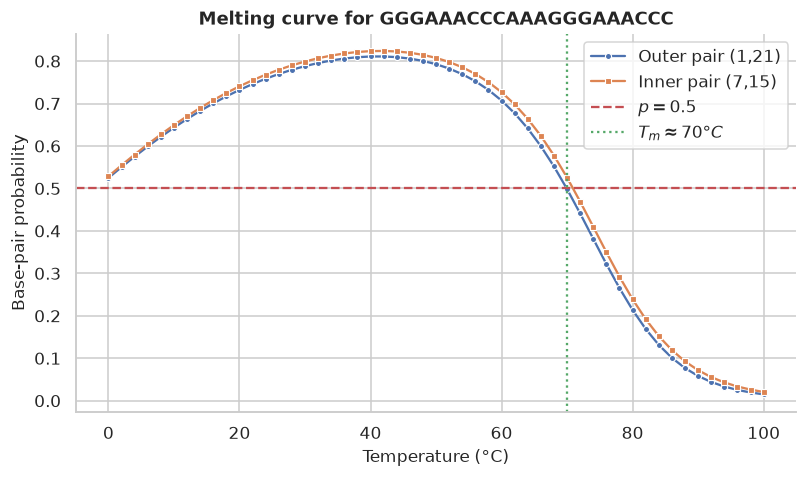

In [3]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
sns.lineplot(data=melt_df, x="temperature", y="p_outer", marker="o", markersize=4,
              color=PALETTE[0], label="Outer pair (1,21)", ax=ax)
sns.lineplot(data=melt_df, x="temperature", y="p_inner", marker="s", markersize=4,
              color=PALETTE[1], label="Inner pair (7,15)", ax=ax)
ax.axhline(0.5, color=PALETTE[3], ls="--", lw=1.5, label=r"$p = 0.5$")

# Approximate Tm: first temperature where p_outer crosses below 0.5.
below_half = melt_df[melt_df["p_outer"] < 0.5]
tm_outer = below_half["temperature"].iloc[0]
ax.axvline(tm_outer, color=PALETTE[2], ls=":", lw=1.5, label=fr"$T_m \approx {tm_outer}°C$")

ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Base-pair probability")
ax.set_title(f"Melting curve for {seq_1}")
ax.legend()
sns.despine(ax=ax)
fig.tight_layout()
plt.show()


**Reading the figure**: both base pairs start near $p \approx 0.5$-$0.6$
at $0°C$ — recall from notebook 3 that this sequence's *ensemble* was never
fully confident, even at $37°C$, due to helix fraying. Probability rises
slightly through room temperature (more order as thermal noise decreases),
peaks around $30$-$40°C$, then falls steadily, crossing $p=0.5$ around
$T_m \approx 70°C$, and is essentially zero by $100°C$ (matching the
all-unpaired MFE we saw appear at high $T$ in the printed table). The two
pairs track each other closely — in this small hairpin, the inner and outer
helices melt together rather than independently.


## 4. Worked example 2 — salt concentration

Now fix the temperature at the default $37°C$ and sweep the monovalent salt
concentration `md.salt` (in $\mathrm{M}$) across a biologically and
experimentally relevant range, from very low-salt buffers ($0.05\,\mathrm{M}$)
to high-salt conditions ($2\,\mathrm{M}$).


In [4]:
salt_values = [0.05, 0.1, 0.15, 0.25, 0.5, 1.0, 1.5, 2.0]
salt_rows = []
for c in salt_values:
    md_s = RNA.md()
    md_s.salt = c
    fc = RNA.fold_compound(seq_1, md_s)
    structure, mfe = fc.mfe()
    salt_rows.append({"salt_M": c, "structure": structure, "mfe": mfe})

salt_df = pd.DataFrame(salt_rows)
salt_df


,salt_M,structure,mfe
0,0.05,(((...(((...)))...))),-3.65
1,0.10,(((...(((...)))...))),-4.21
2,0.15,(((...(((...)))...))),-4.55
3,0.25,(((...(((...)))...))),-4.97
4,0.50,(((...(((...)))...))),-5.43
5,1.00,(((...(((...)))...))),-5.80
6,1.50,(((...(((...)))...))),-5.96
7,2.00,(((...(((...)))...))),-6.06


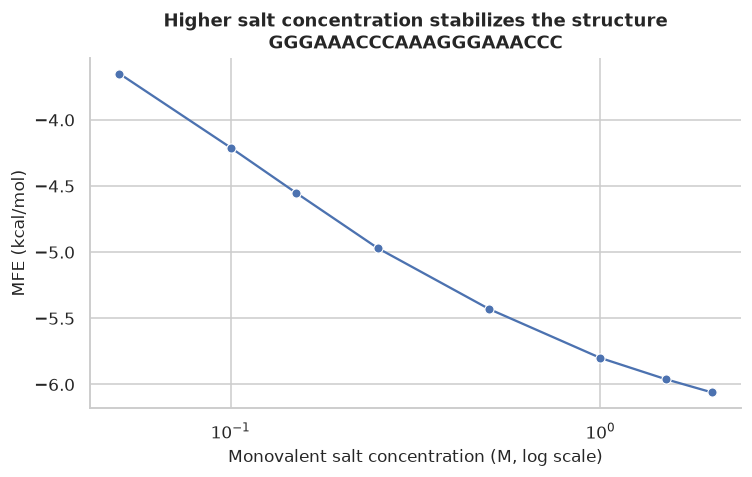

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.lineplot(data=salt_df, x="salt_M", y="mfe", marker="o", color=PALETTE[0], ax=ax)
ax.set_xscale("log")
ax.set_xlabel("Monovalent salt concentration (M, log scale)")
ax.set_ylabel("MFE (kcal/mol)")
ax.set_title(f"Higher salt concentration stabilizes the structure\n{seq_1}")
sns.despine(ax=ax)
fig.tight_layout()
plt.show()


**Reading the figure**: the MFE *structure* is the same
`(((...(((...)))...)))` across this entire range (covariation in
$\Delta G$, not the topology, here), but its *energy* changes substantially —
from $-3.65$ kcal/mol at $50\,\mathrm{mM}$ (a typical low-salt *in vitro*
buffer) to $-6.06$ kcal/mol at $2\,\mathrm{M}$. The relationship is
approximately linear in $\log[\text{salt}]$, consistent with Debye-Hückel-type
electrostatic screening. **A structure prediction made at $1\,\mathrm{M}$
default salt may noticeably overstate stability for a low-salt experimental
buffer** — for marginal structures (small $|\Delta G|$, as in notebook 3 and
5's "switch points"), this could be enough to change which structure is the
MFE.


## 5. Worked example 3 — comparing energy parameter sets

The `params_load_RNA_*` functions swap out ViennaRNA's entire
nearest-neighbor parameter table. Fold `seq_1` with each of the three bundled
RNA parameter sets and compare.


In [6]:
param_sets = {
    "Turner 2004 (default)": RNA.params_load_RNA_Turner2004,
    "Turner 1999": RNA.params_load_RNA_Turner1999,
    "Andronescu 2007": RNA.params_load_RNA_Andronescu2007,
}

param_rows = []
for name, loader in param_sets.items():
    loader()
    fc = RNA.fold_compound(seq_1)
    structure, mfe = fc.mfe()
    param_rows.append({"parameter_set": name, "structure": structure, "mfe": mfe})

# Always restore the default afterwards -- params_load_* is global state!
RNA.params_load_RNA_Turner2004()

param_df = pd.DataFrame(param_rows)
param_df


,parameter_set,structure,mfe
0,Turner 2004 (default),(((...(((...)))...))),-5.8
1,Turner 1999,(((...(((...)))...))),-5.8
2,Andronescu 2007,(((...(((...)))...))),-5.8


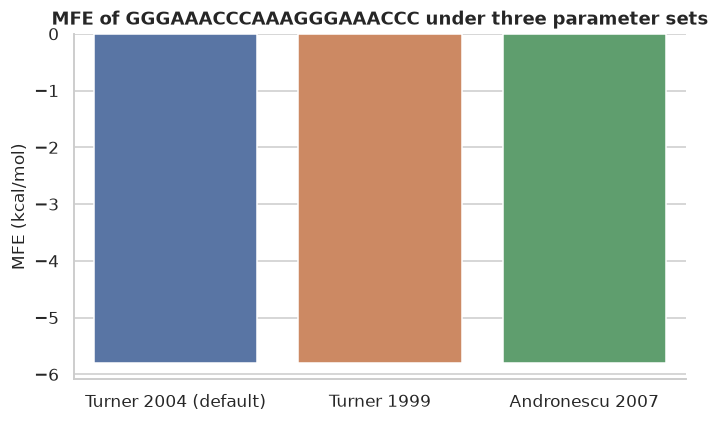

In [7]:
fig, ax = plt.subplots(figsize=(6.5, 4))
sns.barplot(data=param_df, x="parameter_set", y="mfe", hue="parameter_set",
            palette=PALETTE[:3], legend=False, ax=ax)
ax.set_ylabel("MFE (kcal/mol)")
ax.set_xlabel("")
ax.set_title(f"MFE of {seq_1} under three parameter sets")
sns.despine(ax=ax)
fig.tight_layout()
plt.show()


**Reading the output**: for this particular sequence, all three
parameter sets agree exactly, both on structure and energy — Turner 1999,
Turner 2004, and Andronescu 2007 are all refinements of essentially the same
nearest-neighbor framework, and for a simple two-helix hairpin with common
motifs they converge. **This agreement is not guaranteed in general** —
sequences containing less-common motifs (certain tetraloops, GU-rich
junctions, or larger multiloops) can get measurably different $\Delta G$
values, and occasionally different MFE structures, from different parameter
sets. The practical lesson is procedural: **always report which parameter set
was used**, especially when comparing results to other tools or to a previous
ViennaRNA version with a different default.


## 6. Case study — folding the same sequence as DNA

`seq_1` happens to contain no `U` at all — so as a *string*, its DNA
equivalent (`U`$\to$`T`) is letter-for-letter identical (`G`, `A`, `C` are
valid in both alphabets). This makes for a clean, controlled comparison: fold
the exact same string with RNA parameters, then again with DNA parameters,
and attribute *all* of the difference to the parameter set itself.


In [8]:
RNA.params_load_RNA_Turner2004()
structure_rna, mfe_rna = RNA.fold_compound(seq_1).mfe()

RNA.params_load_DNA_Mathews2004()
structure_dna, mfe_dna = RNA.fold_compound(seq_1).mfe()
RNA.params_load_RNA_Turner2004()  # restore default

print(f"Sequence: {seq_1}  (contains no U/T, so identical as RNA or DNA)")
print(f"RNA parameters: {structure_rna}  ({mfe_rna:.2f} kcal/mol)")
print(f"DNA parameters: {structure_dna}  ({mfe_dna:.2f} kcal/mol)")


Sequence: GGGAAACCCAAAGGGAAACCC  (contains no U/T, so identical as RNA or DNA)
RNA parameters: (((...(((...)))...)))  (-5.80 kcal/mol)
DNA parameters: (((...)))...(((...)))  (-2.30 kcal/mol)


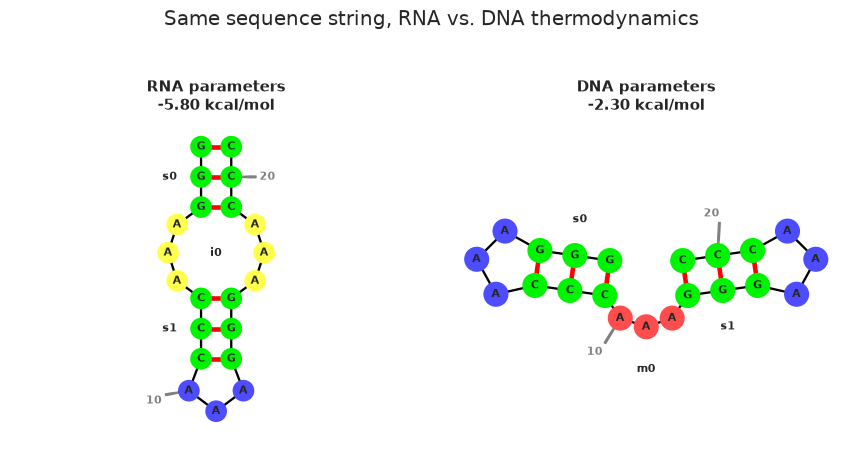

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
draw_structure(axes[0], seq_1, structure_rna, f"RNA parameters\n{mfe_rna:.2f} kcal/mol")
draw_structure(axes[1], seq_1, structure_dna, f"DNA parameters\n{mfe_dna:.2f} kcal/mol")
fig.suptitle("Same sequence string, RNA vs. DNA thermodynamics", y=1.02, fontsize=13)
fig.tight_layout()
plt.show()


**Reading the figure**: with RNA parameters, the sequence forms the
familiar nested two-helix hairpin we've seen throughout notebooks 3-5
($-5.80$ kcal/mol). With DNA parameters, the **same base-pairing pattern is no
longer optimal** — DNA's weaker, B-form-geometry stacking makes the long-range
nested structure less favorable than two short, independent hairpins, at a
much less stable $-2.30$ kcal/mol overall. This is a direct, large effect of
parameter-set choice: it's not just that the numbers shift, but that an
entirely different *topology* becomes optimal. Folding a DNA sequence with RNA
parameters (or vice versa) wouldn't just be "slightly off" — it can point you
at the wrong structure altogether.


## 7. Best practices and common pitfalls

- **`params_load_*` functions are global**, unlike `md.temperature` or
  `md.salt`. Calling `RNA.params_load_DNA_Mathews2004()` changes parameters
  for *every* `fold_compound` created afterward, in this notebook and any
  other code sharing the same process — always restore the default
  (`RNA.params_load_RNA_Turner2004()`) immediately after you're done, as done
  in Sections 5 and 6.
- **`RNA.md()` objects, by contrast, are local** — create a fresh one, set the
  attributes you need (`temperature`, `salt`, `dangles`, ...), and pass it to
  `RNA.fold_compound(seq, md)`. Different fold compounds can use different
  `md` objects safely, even in the same process.
- **Temperature is in °C, salt is in M** — using Kelvin or millimolar
  concentrations will silently give nonsensical (but not obviously "wrong
  looking") results.
- **A melting curve needs `exp_params_rescale(mfe)` at *each* temperature** —
  the rescaling reference energy changes with $T$, since the MFE itself does
  (Section 3). Reusing a rescale factor computed at one temperature for
  another will distort probabilities.
- **Record your model choices.** A complete, reproducible ViennaRNA result
  includes: temperature, salt concentration, parameter set, and any
  `dangles`/`noLP` settings (notebook 2) — five numbers/flags that all
  independently affect $\Delta G$ and can change which structure is reported
  as "the" answer.


## 8. Summary

- **Melting curves** ($p_{ij}$ vs. $T$, via repeated `pf()`/`bpp()` calls)
  reveal $T_m$ — the temperature where a base pair is equally likely to be
  formed or not.
- **Salt concentration** (`md.salt`, in M) shifts $\Delta G$ via an
  electrostatic screening correction — higher salt stabilizes structure,
  roughly linearly in $\log[\text{salt}]$.
- **Parameter sets** (`Turner1999`/`2004`, `Andronescu2007`) are independent
  empirical fits that usually agree but can diverge — set globally via
  `params_load_*`, and must be restored after use.
- **DNA and RNA parameters are not interchangeable** — the same sequence can
  fold into a *different topology*, not just a shifted energy, depending on
  which is used.

**Next**: [09_visualization.ipynb](09_visualization.ipynb) takes a step back
from the *thermodynamics* and focuses on *communicating* ViennaRNA results —
SVG structure drawings, arc diagrams, and pairing-matrix visualizations.


## 9. Exercises

1. In Section 3, the two base pairs $(1,21)$ and $(7,15)$ melt together. Add a
   third curve for a position-specific quantity of your choice (e.g. the
   positional entropy from notebook 3, `fc.positional_entropy()`, at position
   11) to the same plot. Does it peak near $T_m$?
2. In Section 4, the salt sweep used `seq_1`. Repeat it for `seq_2`
   (`CCCCAAAAGGGGAAAACCCCAAAAGGGG`, from notebooks 3 and 5). At very low salt,
   does the MFE *structure* ever change (recall notebook 5's "switch point"
   between the near- and far-pairing alternatives)?
3. In Section 6, find the lowest salt concentration (Section 4's approach,
   applied to the DNA-parameter fold compound) at which the DNA version of
   `seq_1` folds into *any* structure at all (i.e. `mfe < 0`). Compare to the
   RNA version at the same salt concentration.
